# Mutual-information estimator simulations

This notebook simulates the sequential observations used to evaluate the estimator. Each trial contains 12 draws. The latent source is one of two Gaussian distributions with means $-17$ and $17$ and common standard deviation $29$. After every draw except the last, the source switches with probability $0.08$. Observations are clipped to $[-90, 90]$ and rounded to the nearest integer.

Source labels are encoded as `0` (mean $-17$) and `1` (mean $17$). For each trial, `Y` is the source label that generated the final observation.

In [1]:
import numpy as np

In [2]:
def generate_trials(n_trials, balanced_starts=False, seed=None):
    """Generate trials from a two-state switching Gaussian process.

    Parameters
    ----------
    n_trials : int
        Number of independent trials to generate.
    balanced_starts : bool, default=False
        If True, exactly half of the trials start in each source
        distribution. This requires an even ``n_trials``.
    seed : int or None, default=None
        Seed for NumPy's random-number generator. Use an integer for
        reproducible simulations.

    Returns
    -------
    X : ndarray of int, shape (n_trials, 12)
        Clipped and rounded observations for each trial.
    Y : ndarray of int, shape (n_trials,)
        Identity of the source for the final draw: 0 denotes the Gaussian
        with mean -17 and 1 denotes the Gaussian with mean 17.
    """
    if isinstance(n_trials, (bool, np.bool_)) or not isinstance(n_trials, (int, np.integer)):
        raise TypeError("n_trials must be an integer")
    if n_trials < 0:
        raise ValueError("n_trials must be non-negative")
    if balanced_starts and n_trials % 2:
        raise ValueError("balanced_starts=True requires an even n_trials")

    rng = np.random.default_rng(seed)
    n_draws = 12
    source_means = np.array([-17.0, 17.0])

    if balanced_starts:
        starts = np.repeat([0, 1], n_trials // 2)
        rng.shuffle(starts)
    else:
        starts = rng.integers(0, 2, size=n_trials)

    # switches[:, j] indicates whether the source changes between draws
    # j and j + 1. Cumulative parity therefore gives the source at each draw.
    switches = rng.random((n_trials, n_draws - 1)) < 0.08
    source_paths = np.column_stack(
        [starts, starts[:, None] ^ np.logical_xor.accumulate(switches, axis=1)]
    ).astype(int)

    raw_draws = rng.normal(loc=source_means[source_paths], scale=29.0)
    X = np.rint(np.clip(raw_draws, -90, 90)).astype(int)
    Y = source_paths[:, -1].copy()
    return X, Y

## Example and basic checks

The seed makes this example reproducible. The assertions verify the output shapes, integer-valued bounds, and both source labels.

In [3]:
X, Y = generate_trials(10_000, balanced_starts=True, seed=2026)

assert X.shape == (10_000, 12)
assert Y.shape == (10_000,)
assert np.issubdtype(X.dtype, np.integer)
assert np.all((-90 <= X) & (X <= 90))
assert set(np.unique(Y)).issubset({0, 1})

X[:5], Y[:5]

(array([[ -2,  50,  48,   0,  56,  13,  20,  28,  29,  29,  38,  18],
        [-23,   6, -57, -35,  18, -53,  18, -33,  -6,   2, -70,  -1],
        [ 15,  33,  15, -22,  43, -10,  39,  62,   0, -70, -11, -32],
        [ 41,  44,  49,   5, -22, -55, -39, -20, -55,  30,  12,  -4],
        [ -2,  42, -60, -20, -37,  42,  13,  40,   0,   3, -22,  32]]),
 array([1, 0, 0, 0, 1]))

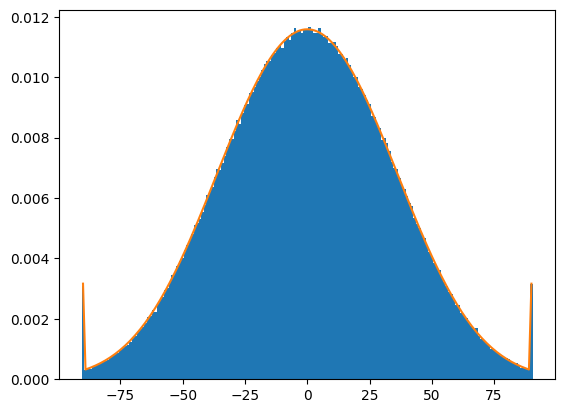

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import norm

mean0, mean1 = -17, 17
std = 29

X2 = np.arange(-90, 91)
p_XgY0 = np.zeros(181)
p_XgY1 = np.zeros(181)

p_XgY0[0] = norm.cdf(-90.5,loc=mean0,scale=std)
p_XgY1[0] = norm.cdf(-90.5,loc=mean1,scale=std)

p_XgY0[-1] = 1 - norm.cdf(90.5,loc=mean0,scale=std)
p_XgY1[-1] = 1 - norm.cdf(90.5,loc=mean1,scale=std)
for i in range(181):
    p_XgY0[i] += norm.cdf(X2[i]+0.5,loc=mean0,scale=std) - norm.cdf(X2[i]-0.5,loc=mean0,scale=std)
    p_XgY1[i] += norm.cdf(X2[i]+0.5,loc=mean1,scale=std) - norm.cdf(X2[i]-0.5,loc=mean1,scale=std)

p_X = 0.5 * p_XgY0 + 0.5 * p_XgY1

X, Y = generate_trials(100000,balanced_starts=True)
plt.hist(X.ravel(),bins=np.arange(-90.5,91.5,1),density=True)
plt.plot(X2, p_X, label="p(X)")

In [5]:
def P_source_g_samples(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    # P_sample_g_neg = norm(loc=mean_neg, scale=std)
    # P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg[samples_arr + 90]
    Lpos = P_sample_g_pos[samples_arr + 90]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1, keepdims=True)
    return P.squeeze()

# def P_source_g_samples_alt(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
#     P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
#     P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
#     # P_sample_g_neg = norm(loc=mean_neg, scale=std)
#     # P_sample_g_pos = norm(loc=mean_pos, scale=std)
#     Lneg = P_sample_g_neg[samples_arr + 90]
#     Lpos = P_sample_g_pos[samples_arr + 90]
#     L = np.stack((Lneg,Lpos),axis=1).T
#     H = np.array([
#         [1-h, h],
#         [h, 1-h]
#     ])
#     P = P0.copy()
#     if window_size is not None:
#         L = L[:,-window_size:]
#         # L = L[:,:,-window_size:]
#     # for ii in range(L.shape[2]):
#     #     P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
#     # P = P / P.sum(axis=1, keepdims=True)
#     # return P.squeeze()
#     for ii in range(L.shape[1]):
#         P = L[:,ii][:,np.newaxis] * (H @ P)
#     P = P / P.sum(axis=0,keepdims=True)
#     return P

In [6]:
mean_neg = -17
mean_pos = 17
std = 29
h = 0.08
P0 = np.array([[0.5],[0.5]])

P = P_source_g_samples(X, mean_neg, mean_pos, std, h, P0, window_size=None)

In [7]:
def largeN_mutual_info(P,Y):
    # P = posterior probabilities of the source given the samples
    # Y = true source labels

    p_Y = np.bincount(Y) / len(Y)
    H_Y = -np.sum(p_Y * np.log2(p_Y))

    Yoh = np.eye(np.max(Y) + 1)[Y]
    # H_YgP = -np.sum(Yoh * np.log2(P)) / Y.shape[0]
    H_YgP = -np.sum((1/Y.shape[0]) * np.sum(P * np.log2(P),axis=1,keepdims=True))

    # I_PY = np.sum(Yoh*(1/Y.shape[0])*np.log2(P/p_Y.reshape(-1,2)))

    # return I_PY
    return H_Y - H_YgP

In [8]:
P = P_source_g_samples(X, mean_neg, mean_pos, std, h, P0, window_size=None)

largeN_mutual_info(P, Y)

0.4202037626987095

In [9]:
import utilities as utils

utils.compute_I_XR_emp(P)

0.4202032452862935

In [10]:
optimal_choices = np.argmax(P, axis=1)
optimal_choices

array([0, 0, 0, ..., 0, 0, 0])

In [11]:
def mutual_information(A,B):
    A_unique = np.unique(A)
    B_unique = np.unique(B)
    p_AB = np.array([[np.mean((A==a) & (B==b)) for b in B_unique] for a in A_unique])
    p_A = p_AB.sum(axis=1, keepdims=True)
    p_B = p_AB.sum(axis=0, keepdims=True)
    mi = np.nansum(p_AB * np.log2(p_AB/(p_A * p_B)))
    return mi

mutual_information(optimal_choices, Y)

0.31675922740921825

(array([8049., 9835., 8520., 7214., 6277., 5494., 4803., 4390., 3930.,
        3669., 3382., 3129., 2984., 2786., 2681., 2594., 2577., 2433.,
        2329., 2176., 2126., 2176., 2201., 2131., 2114., 2114., 2131.,
        2201., 2176., 2126., 2176., 2329., 2433., 2577., 2594., 2681.,
        2786., 2984., 3129., 3382., 3669., 3930., 4390., 4803., 5494.,
        6277., 7214., 8520., 9835., 8049.]),
 array([0.0017482 , 0.02167827, 0.04160834, 0.06153842, 0.08146849,
        0.10139856, 0.12132863, 0.1412587 , 0.16118878, 0.18111885,
        0.20104892, 0.22097899, 0.24090906, 0.26083914, 0.28076921,
        0.30069928, 0.32062935, 0.34055942, 0.3604895 , 0.38041957,
        0.40034964, 0.42027971, 0.44020978, 0.46013986, 0.48006993,
        0.5       , 0.51993007, 0.53986014, 0.55979022, 0.57972029,
        0.59965036, 0.61958043, 0.6395105 , 0.65944058, 0.67937065,
        0.69930072, 0.71923079, 0.73916086, 0.75909094, 0.77902101,
        0.79895108, 0.81888115, 0.83881122, 0.8587413 , 

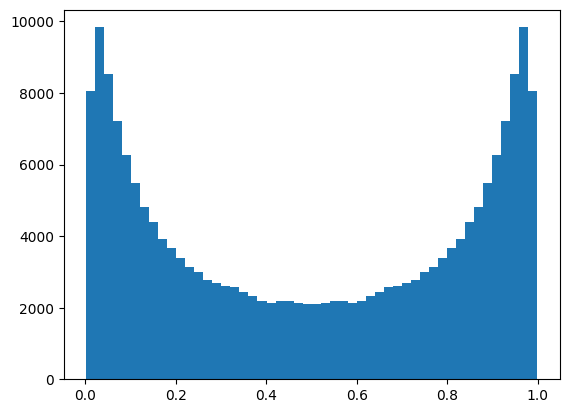

In [12]:
plt.hist(P.ravel(), bins=50)

In [13]:
from scipy.special import digamma


def discrete_continuous_info(
    d: np.ndarray,
    c: np.ndarray,
    k: int = 3,
    base: float = np.e,
) -> tuple[float, np.ndarray]:
    """
    Estimate mutual information between a discrete vector-valued variable d
    and a continuous vector-valued variable c using nearest-neighbor
    statistics.

    Parameters
    ----------
    d : array_like, shape (n_discrete_features, n_samples)
        Discrete observations. Each sample is a column.

    c : array_like, shape (n_continuous_features, n_samples)
        Continuous observations. Each sample is a column.

    k : int, default=3
        Number of within-symbol nearest neighbors.

    base : float, default=e
        Logarithm base used for the returned mutual information.
        Use base=2 for bits and base=np.e for nats.

    Returns
    -------
    f : float
        Estimated mutual information.

    V : ndarray, shape (n_samples,)
        Per-sample neighborhood-volume quantity calculated by the
        original MATLAB implementation.

    Notes
    -----
    This is a direct translation of the MATLAB implementation, including
    its handling of rare discrete symbols and its definition of V.
    """
    d = np.asarray(d)
    c = np.asarray(c, dtype=float)

    if d.ndim == 1:
        d = d[np.newaxis, :]
    if c.ndim == 1:
        c = c[np.newaxis, :]

    if d.ndim != 2 or c.ndim != 2:
        raise ValueError("d and c must be one- or two-dimensional arrays.")

    if d.shape[1] != c.shape[1]:
        raise ValueError(
            "d and c must contain the same number of samples "
            "(the same number of columns)."
        )

    if d.shape[1] == 0:
        raise ValueError("At least one sample is required.")

    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError("k must be a positive integer.")

    if not np.isfinite(base) or base <= 0 or np.isclose(base, 1.0):
        raise ValueError("base must be positive and different from 1.")

    n_samples = d.shape[1]

    # Bin continuous samples according to the unique discrete vectors.
    #
    # np.unique operates on rows, so transpose d to make samples rows.
    _, symbol_ids = np.unique(d.T, axis=0, return_inverse=True)
    n_symbols = symbol_ids.max() + 1

    c_split = []
    cs_indices = []

    for symbol_id in range(n_symbols):
        indices = np.flatnonzero(symbol_ids == symbol_id)
        cs_indices.append(indices)
        c_split.append(c[:, indices])

    # Compute the neighbor statistics.
    m_tot = 0.0
    av_psi_Nd = 0.0
    psi_ks = 0.0
    V = np.zeros(n_samples, dtype=float)

    for c_bin, indices in zip(c_split, cs_indices):
        n_bin = c_bin.shape[1]
        one_k = min(k, n_bin - 1)

        if one_k > 0:
            for local_pivot, global_pivot in enumerate(indices):
                pivot = c_bin[:, local_pivot]

                # Distances to samples having the same discrete symbol.
                within_distances = np.linalg.norm(
                    c_bin - pivot[:, np.newaxis],
                    axis=0,
                )

                # Element zero in the sorted array is the pivot itself.
                eps_over_2 = np.partition(
                    within_distances,
                    one_k,
                )[one_k]

                # Distances to all continuous samples.
                all_distances = np.linalg.norm(
                    c - pivot[:, np.newaxis],
                    axis=0,
                )

                # Include boundary ties, then remove the pivot.
                m = max(np.count_nonzero(all_distances <= eps_over_2) - 1, 0)

                m_tot += digamma(m)

                # Faithfully preserves size(d, 1) from the MATLAB function.
                V[global_pivot] = (2.0 * eps_over_2) ** d.shape[0]

        else:
            # Faithfully preserve the MATLAB singleton-bin behavior.
            m_tot += digamma(n_symbols * 2)

        p_d = n_bin / n_samples
        av_psi_Nd += p_d * digamma(n_bin)
        psi_ks += p_d * digamma(max(one_k, 1))

    f = (
        digamma(n_samples)
        - av_psi_Nd
        + psi_ks
        - m_tot / n_samples
    ) / np.log(base)

    return float(f), V

In [14]:
MIknn, V = discrete_continuous_info(d=Y.reshape(1,-1), c=P[:,1].reshape(1,-1), k=3)
MIknn

0.2880647474280132

In [15]:
X.T.shape

(12, 100000)

In [16]:
MIknn, V = discrete_continuous_info(d=Y.reshape(1,-1), c=X.T, k=3)
MIknn

0.2837062516470606

In [17]:
from scipy.special import softmax

Ntrials = 1500
Niters = 10
betas = [3]
Ixr = {}
Ixr_est = {}
Ixr_ref = {}
Ixr_est_ref = {}

rng = np.random.default_rng(2026)

Xref, Yref = generate_trials(100000,balanced_starts=True)
Pref = P_source_g_samples(Xref, mean_neg, mean_pos, std, h, P0, window_size=None)

for beta in betas:
    Ixr[beta] = np.zeros((Niters))
    Ixr_est[beta] = np.zeros((Niters))
    p_RgX_ref = softmax(beta * Pref, axis=1)
    choices_ref = rng.multinomial(1,p_RgX_ref).argmax(axis=1)
    Ixr_ref[beta] = utils.compute_I_XR_emp(p_RgX_ref)
    Ixr_est_ref[beta] = discrete_continuous_info(d=choices_ref.reshape(1,-1), c=Xref.T, k=3)[0]
    for i in range(Niters):
        X, Y = generate_trials(Ntrials, balanced_starts=True)
        P = P_source_g_samples(X, mean_neg, mean_pos, std, h, P0, window_size=None)
        p_RgX = softmax(beta * P, axis=1)
        choices = rng.multinomial(1,p_RgX).argmax(axis=1)
        Ixr[beta][i] = utils.compute_I_XR_emp(p_RgX)
        Ixr_est[beta][i] = discrete_continuous_info(d=choices.reshape(1,-1), c=X.T, k=3)[0]

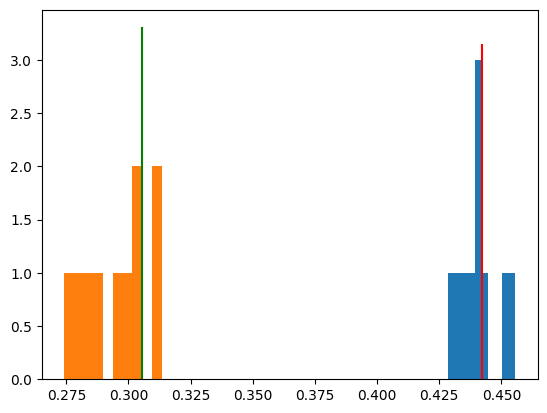

In [19]:
plt.hist(Ixr[3])
plt.hist(Ixr_est[3])
plt.vlines(Ixr_ref[3],0,plt.gca().get_ylim()[1],color='r')
plt.vlines(Ixr_est_ref[3],0,plt.gca().get_ylim()[1],color='g')

In [ ]:
import scipy.spatial as ss
from math import log

def Mixed_KSG(x,y,k=5):
	'''
		Estimate the mutual information I(X;Y) of X and Y from samples {x_i, y_i}_{i=1}^N
		Using *Mixed-KSG* mutual information estimator

		Input: x: 2D array of size N*d_x (or 1D list of size N if d_x = 1)
		y: 2D array of size N*d_y (or 1D list of size N if d_y = 1)
		k: k-nearest neighbor parameter

		Output: one number of I(X;Y)
	'''

	assert len(x)==len(y), "Lists should have same length"
	assert k <= len(x)-1, "Set k smaller than num. samples - 1"
	N = len(x)
	if x.ndim == 1:
		x = x.reshape((N,1))
	dx = len(x[0])   	
	if y.ndim == 1:
		y = y.reshape((N,1))
	dy = len(y[0])
	data = np.concatenate((x,y),axis=1)

	tree_xy = ss.cKDTree(data)
	tree_x = ss.cKDTree(x)
	tree_y = ss.cKDTree(y)

	knn_dis = [tree_xy.query(point,k+1,p=float('inf'))[0][k] for point in data]
	ans = 0

	for i in range(N):
		kp, nx, ny = k, k, k
		if knn_dis[i] == 0:
			kp = len(tree_xy.query_ball_point(data[i],1e-15,p=float('inf')))
			nx = len(tree_x.query_ball_point(x[i],1e-15,p=float('inf')))
			ny = len(tree_y.query_ball_point(y[i],1e-15,p=float('inf')))
		else:
			nx = len(tree_x.query_ball_point(x[i],knn_dis[i]-1e-15,p=float('inf')))
			ny = len(tree_y.query_ball_point(y[i],knn_dis[i]-1e-15,p=float('inf')))
		ans += (digamma(kp) + log(N) - digamma(nx) - digamma(ny))/N
	return ans

In [ ]:
Mixed_KSG(Xref, choices_ref, k=5)

-0.3617120797896123

In [ ]:
Xscaled = Xref / 90
Mixed_KSG(Xscaled, choices_ref, k=5)

KeyboardInterrupt: 

In [ ]:
Xscaled = X / 90
Mixed_KSG(Xscaled, choices, k=5)

0.3824998532350535

In [ ]:
from scipy.special import softmax

Ntrials = 1500
Niters = 10
betas = [1, 3, 5]
Ixr = {}
Ixr_est = {}
Ixr_ref = {}
Ixr_est_ref = {}

rng = np.random.default_rng(2026)

Xref, Yref = generate_trials(100000,balanced_starts=True)
Pref = P_source_g_samples(Xref, mean_neg, mean_pos, std, h, P0, window_size=None)

for beta in betas:
    Ixr[beta] = np.zeros((Niters))
    Ixr_est[beta] = np.zeros((Niters))
    p_RgX_ref = softmax(beta * Pref, axis=1)
    choices_ref = rng.multinomial(1,p_RgX_ref).argmax(axis=1)
    Ixr_ref[beta] = utils.compute_I_XR_emp(p_RgX_ref)
    Ixr_est_ref[beta] = Mixed_KSG(Xref/90,choices_ref,k=5)
    for i in range(Niters):
        X, Y = generate_trials(Ntrials, balanced_starts=True)
        P = P_source_g_samples(X, mean_neg, mean_pos, std, h, P0, window_size=None)
        p_RgX = softmax(beta * P, axis=1)
        choices = rng.multinomial(1,p_RgX).argmax(axis=1)
        Ixr[beta][i] = utils.compute_I_XR_emp(p_RgX)
        Ixr_est[beta][i] = Mixed_KSG(X/90,choices,k=5)

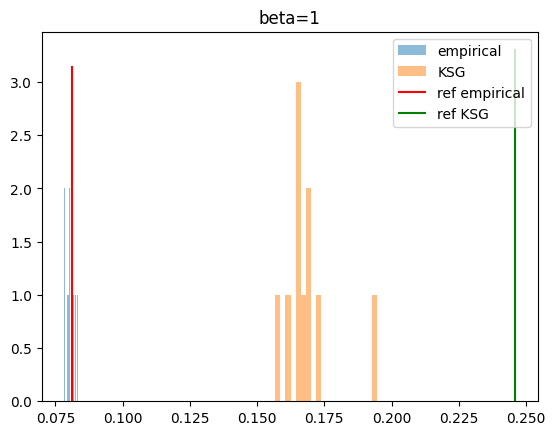

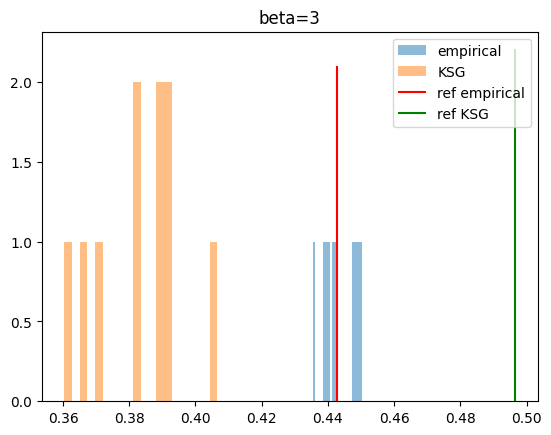

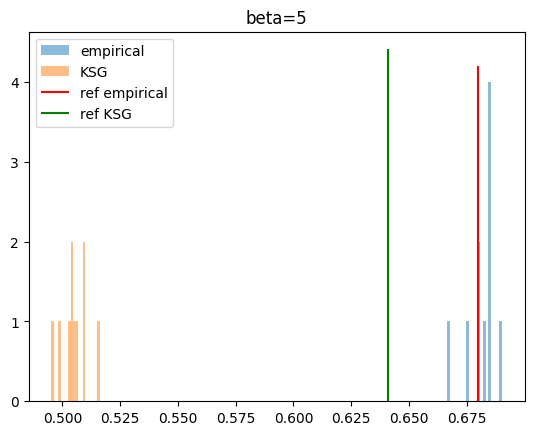

In [ ]:
for beta in betas:
    plt.figure()
    plt.hist(Ixr[beta],bins=20,alpha=0.5,label='empirical')
    plt.hist(Ixr_est[beta],bins=20,alpha=0.5,label='KSG')
    plt.vlines(Ixr_ref[beta],0,plt.gca().get_ylim()[1],color='r',label='ref empirical')
    plt.vlines(Ixr_est_ref[beta],0,plt.gca().get_ylim()[1],color='g',label='ref KSG')
    plt.title(f'beta={beta}')
    plt.legend()

In [20]:
from scipy.special import softmax

from choice_information import (
    default_model_library,
    estimate_choice_information,
    bootstrap_choice_information,
    plot_choice_information_diagnostics,
    plot_bootstrap_choice_information,
)

Ntrials = 1500
Niters = 10
betas = [1, 3, 5]
Ixr = {}
Ixr_est = {}
Ixr_ref = {}
Ixr_est_ref = {}

rng = np.random.default_rng(2026)

Xref, Yref = generate_trials(100000,balanced_starts=True)
Pref = P_source_g_samples(Xref, mean_neg, mean_pos, std, h, P0, window_size=None)

for beta in betas:
    Ixr[beta] = np.zeros((Niters))
    Ixr_est[beta] = np.zeros((Niters))
    p_RgX_ref = softmax(beta * Pref, axis=1)
    choices_ref = rng.multinomial(1,p_RgX_ref).argmax(axis=1)
    Ixr_ref[beta] = utils.compute_I_XR_emp(p_RgX_ref)
    result = estimate_choice_information(
        Xref,
        choices_ref,
        fold_mode="random",
        n_splits=5,
        inner_n_splits=3,
        random_state=2026,
    )
    Ixr_est_ref[beta] = result["mi_lower_bound_bits"]
    for i in range(Niters):
        X, Y = generate_trials(Ntrials, balanced_starts=True)
        P = P_source_g_samples(X, mean_neg, mean_pos, std, h, P0, window_size=None)
        p_RgX = softmax(beta * P, axis=1)
        choices = rng.multinomial(1,p_RgX).argmax(axis=1)
        Ixr[beta][i] = utils.compute_I_XR_emp(p_RgX)
        result = estimate_choice_information(
            X,
            choices,
            fold_mode="random",
            n_splits=5,
            inner_n_splits=3,
            random_state=2026,
        )
        Ixr_est[beta][i] = result["mi_lower_bound_bits"]

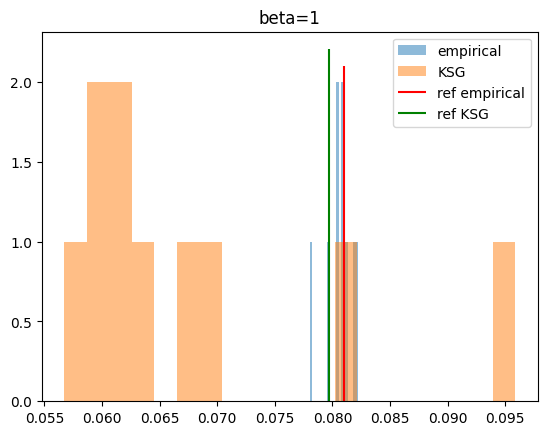

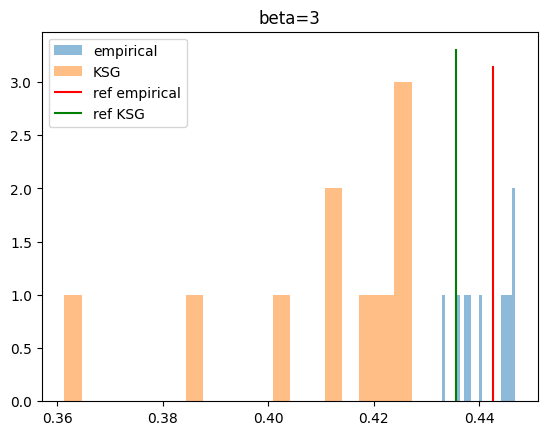

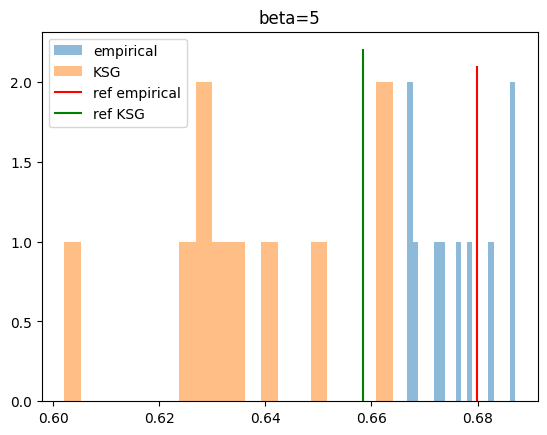

In [ ]:
for beta in betas:
    plt.figure()
    plt.hist(Ixr[beta],bins=20,alpha=0.5,label='empirical')
    plt.hist(Ixr_est[beta],bins=20,alpha=0.5,label='KSG')
    plt.vlines(Ixr_ref[beta],0,plt.gca().get_ylim()[1],color='r',label='ref empirical')
    plt.vlines(Ixr_est_ref[beta],0,plt.gca().get_ylim()[1],color='g',label='ref KSG')
    plt.title(f'beta={beta}')
    plt.legend()

## Softmax choice policy

The policy applies a softmax to the two posterior source probabilities. Thus, `beta=0` produces random choices and larger values increasingly favor the source with the larger posterior probability.

In [212]:
def softmax_choice_policy(P_source_g_samples, beta):
    """Return p(R | X) by applying a softmax to p(Y | X)."""
    P_source_g_samples = np.asarray(P_source_g_samples, dtype=float)
    if P_source_g_samples.ndim != 2 or P_source_g_samples.shape[1] != 2:
        raise ValueError("P_source_g_samples must have shape (n_trials, 2)")
    if not np.all(np.isfinite(P_source_g_samples)):
        raise ValueError("P_source_g_samples must contain only finite values")
    if not np.isfinite(beta) or beta < 0:
        raise ValueError("beta must be a finite, non-negative number")

    logits = beta * P_source_g_samples
    logits -= logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

## Repeated choice simulations

The trial set and posterior probabilities are generated once and held fixed. Each iteration samples fresh choices. We estimate `p(Y | R)` from those choices before calling `largeN_mutual_info`, yielding an estimate of `I(R; Y)`.

In [213]:
def compute_joint_distribution(choices, Y):
    counts = np.bincount(2 * choices + Y, minlength=4).reshape(2, 2)
    return counts / counts.sum()

def compute_I_RY(choices, Y):
    p_RY = compute_joint_distribution(choices, Y)
    p_R = p_RY.sum(axis=1, keepdims=True)
    p_Y = p_RY.sum(axis=0, keepdims=True)
    return np.sum(p_RY * np.log2(p_RY / (p_R * p_Y)))

In [217]:
def posterior_source_given_choice(choices, Y):
    """Estimate p(Y | R) and return it for each trial's choice R."""
    choices = np.asarray(choices, dtype=int)
    Y = np.asarray(Y, dtype=int)
    if choices.shape != Y.shape or choices.ndim != 1:
        raise ValueError("choices and Y must be one-dimensional arrays of equal length")
    if np.any((choices < 0) | (choices > 1)) or np.any((Y < 0) | (Y > 1)):
        raise ValueError("choices and Y must contain only labels 0 and 1")

    counts = np.bincount(2 * choices + Y, minlength=4).reshape(2, 2)
    row_totals = counts.sum(axis=1, keepdims=True)
    p_Y = np.bincount(Y, minlength=2) / Y.size
    p_Y_given_choice = np.divide(
        counts,
        row_totals,
        out=np.broadcast_to(p_Y, counts.shape).copy(),
        where=row_totals != 0,
    )
    return p_Y_given_choice[choices]


N_TRIALS = 1_000_000
N_ITERATIONS = 100
BETA = 30.0
SIMULATION_SEED = 2026
CHOICE_SEED = 2027

# Generate one shared large-N trial set for every choice simulation.
X_large, Y_large = generate_trials(
    N_TRIALS, balanced_starts=True, seed=SIMULATION_SEED
)
P_large = P_source_g_samples(
    X_large, mean_neg, mean_pos, std, h, P0, window_size=None
)
choice_probabilities = softmax_choice_policy(P_large, BETA)

rng = np.random.default_rng(CHOICE_SEED)
mutual_info_estimates = np.empty(N_ITERATIONS)
for iteration in range(N_ITERATIONS):
    choices = (rng.random(N_TRIALS) < choice_probabilities[:, 1]).astype(int)
    P_Y_given_choice = posterior_source_given_choice(choices, Y_large)
    mutual_info_estimates[iteration] = largeN_mutual_info(P_Y_given_choice, Y_large)

mutual_info_estimates.mean(), mutual_info_estimates.std(ddof=1)

(0.31827613766745094, 0.00020798409191856185)

In [220]:
from scipy.special import softmax
p_RgX = softmax(BETA * P_large, axis=1)
p_RgX

array([[6.80981638e-06, 9.99993190e-01],
       [2.11367249e-11, 1.00000000e+00],
       [1.00000000e+00, 2.52587581e-13],
       ...,
       [6.94322276e-03, 9.93056777e-01],
       [1.00000000e+00, 2.28642656e-11],
       [9.98997017e-01, 1.00298293e-03]])

In [221]:
P_large

array([[0.30171436, 0.69828564],
       [0.09033318, 0.90966682],
       [0.98345031, 0.01654969],
       ...,
       [0.41728297, 0.58271703],
       [0.90835743, 0.09164257],
       [0.61506289, 0.38493711]])

In [222]:
optimal_choices = np.argmax(P_large, axis=1)
optimal_choices

array([1, 1, 0, ..., 1, 0, 0])

In [223]:
def mutual_info(A,B):
    # A and B are discrete random variables represented as integer arrays
    p_A = np.bincount(A) / len(A)
    p_B = np.bincount(B) / len(B)
    H_A = -np.sum(p_A * np.log2(p_A))
    H_B = -np.sum(p_B * np.log2(p_B))

    AB = np.c_[(A,B)]
    unique_AB, counts_AB = np.unique(AB, axis=0, return_counts=True)
    p_AB = counts_AB / len(A)
    H_AB = -np.sum(p_AB * np.log2(p_AB))

    return H_A + H_B - H_AB

In [224]:
mutual_info(optimal_choices,Y_large)

0.3192952229610275

In [186]:
compute_I_RY(optimal_choices, Y_large)

0.3192952229610274

In [96]:
compute_I_RY(choices, Y_large)

0.3180254682768182

In [83]:
P_Y_given_choice

array([[0.1814274 , 0.8185726 ],
       [0.1814274 , 0.8185726 ],
       [0.81968871, 0.18031129],
       ...,
       [0.1814274 , 0.8185726 ],
       [0.81968871, 0.18031129],
       [0.81968871, 0.18031129]])

In [89]:
choice_probabilities

array([[6.80981638e-06, 9.99993190e-01],
       [2.11367249e-11, 1.00000000e+00],
       [1.00000000e+00, 2.52587581e-13],
       ...,
       [6.94322276e-03, 9.93056777e-01],
       [1.00000000e+00, 2.28642656e-11],
       [9.98997017e-01, 1.00298293e-03]])

In [90]:
P_large

array([[0.30171436, 0.69828564],
       [0.09033318, 0.90966682],
       [0.98345031, 0.01654969],
       ...,
       [0.41728297, 0.58271703],
       [0.90835743, 0.09164257],
       [0.61506289, 0.38493711]])

In [93]:
np.unique(choices * 2 + Y_large,return_counts=True)

(array([0, 1, 2, 3]), array([410096,  90211,  90658, 409035]))

In [88]:
Y

array([1, 0, 0, ..., 0, 1, 0])

In [ ]:
counts = np.bincount(2 * choices + Y_large, minlength=4).reshape(2, 2)
p_RY = counts / counts.sum()

array([[0.410096, 0.090211],
       [0.090658, 0.409035]])

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mutual_info_estimates, bins=15, color="tab:blue", alpha=0.8, edgecolor="white")
ax.axvline(
    mutual_info_estimates.mean(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {mutual_info_estimates.mean():.4f} bits",
)
ax.set(
    xlabel=r"Estimated $I(R;Y)$ (bits)",
    ylabel="Number of simulations",
    title=f"Softmax policy MI estimates (beta={BETA:g}, N={N_TRIALS:,})",
)
ax.legend()
fig.tight_layout()
plt.show()